In [ ]:
!pip install -q azure-storage-file-datalake pyarrow pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 737.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.8/287.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.9/220.9 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.2/438.2 kB 15.5 MB/s eta 0:00:00


In [ ]:
import io
import pandas as pd
import numpy as np
from azure.storage.filedatalake import DataLakeServiceClient
from google.colab import userdata
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
# Retrieve connection string from Colab Secrets
connection_string = userdata.get('AZURE_STORAGE_CONNECTION_STRING')

# Authenticate with Azure Data Lake Gen2
service_client = DataLakeServiceClient.from_connection_string(connection_string)

# Access the /silver container and target file
silver_client = service_client.get_file_system_client(file_system="silver")
file_client = silver_client.get_file_client("silver_claims_fused.parquet")

# Download the file directly into memory
print("Downloading Parquet file from Azure...")
downloaded_bytes = file_client.download_file().readall()

In [ ]:
df = pd.read_parquet(io.BytesIO(downloaded_bytes))

# Verify successful load
print(f"Dataset loaded successfully with shape: {df.shape}")
display(df.head())

Dataset loaded successfully with shape: (30000, 25)


,policy_id,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_date,...,incident_city,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported,adjuster_notes
0,POL100000,GA,400,1430.78,74,OTHER,High School,Manager,reading,2024-06-13,...,Charlesville,6,1,4,0,Yes,8161.36,11677.60,Y,Claimant's description is inconsistent with th...
1,POL100001,PA,300,854.49,74,MALE,College,Lawyer,chess,2025-03-23,...,Joshuaberg,0,3,4,5,No,18561.79,18027.81,N,Insured was cooperative. Proceeding with stand...
2,POL100002,MI,400,1247.28,28,OTHER,PhD,Doctor,reading,2025-01-26,...,Reynoldsfurt,14,4,4,1,No,10734.61,10375.59,N,Minor fender bender. No red flags identified d...
3,POL100003,CA,600,622.42,37,MALE,PhD,Teacher,yachting,2024-06-03,...,Josephchester,22,3,3,5,No,13188.92,14204.34,N,Insured was cooperative. Proceeding with stand...
4,POL100004,MI,700,1458.17,31,OTHER,PhD,Sales,reading,2024-05-21,...,Caitlinfort,18,4,2,4,No,21864.69,24038.84,N,Standard claim. Damage is consistent with a lo...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   policy_id                    30000 non-null  object        
 1   policy_state                 30000 non-null  object        
 2   policy_deductible            30000 non-null  int64         
 3   policy_annual_premium        30000 non-null  float64       
 4   insured_age                  30000 non-null  int64         
 5   insured_sex                  30000 non-null  object        
 6   insured_education_level      30000 non-null  object        
 7   insured_occupation           30000 non-null  object        
 8   insured_hobbies              30000 non-null  object        
 9   incident_date                30000 non-null  datetime64[us]
 10  incident_type                30000 non-null  object        
 11  collision_type               30000 non-nu

In [ ]:
print(df.head())

   policy_id policy_state  policy_deductible  policy_annual_premium  \
0  POL100000           GA                400                1430.78   
1  POL100001           PA                300                 854.49   
2  POL100002           MI                400                1247.28   
3  POL100003           CA                600                 622.42   
4  POL100004           MI                700                1458.17   

   insured_age insured_sex insured_education_level insured_occupation  \
0           74       OTHER             High School            Manager   
1           74        MALE                 College             Lawyer   
2           28       OTHER                     PhD             Doctor   
3           37        MALE                     PhD            Teacher   
4           31       OTHER                     PhD              Sales   

  insured_hobbies incident_date  ...  incident_city incident_hour_of_the_day  \
0         reading    2024-06-13  ...   Charlesville   

In [ ]:
df['fraud_reported'].value_counts(normalize=True)

,proportion
fraud_reported,
N,0.885333
Y,0.114667


In [ ]:
df.drop(columns=["policy_id", "adjuster_notes", "incident_city"], inplace=True)

In [ ]:
df["fraud_reported"] = df["fraud_reported"].map({"Y": 1, "N": 0})

In [ ]:
df.head()

,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_date,incident_type,...,authorities_contacted,incident_state,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported
0,GA,400,1430.78,74,OTHER,High School,Manager,reading,2024-06-13,Parked Car,...,None,MI,6,1,4,0,Yes,8161.36,11677.60,1
1,PA,300,854.49,74,MALE,College,Lawyer,chess,2025-03-23,Vehicle Theft,...,None,OH,0,3,4,5,No,18561.79,18027.81,0
2,MI,400,1247.28,28,OTHER,PhD,Doctor,reading,2025-01-26,Parked Car,...,Police,MI,14,4,4,1,No,10734.61,10375.59,0
3,CA,600,622.42,37,MALE,PhD,Teacher,yachting,2024-06-03,Parked Car,...,Police,NC,22,3,3,5,No,13188.92,14204.34,0
4,MI,700,1458.17,31,OTHER,PhD,Sales,reading,2024-05-21,Single Vehicle Collision,...,Fire,NY,18,4,2,4,No,21864.69,24038.84,0


In [ ]:
df["authorities_contacted"] = df["authorities_contacted"].fillna("None")

In [ ]:
df.groupby('authorities_contacted')['fraud_reported'].value_counts(normalize=True)

authorities_contacted  fraud_reported
Ambulance              0                 0.915185
                       1                 0.084815
Fire                   0                 0.916237
                       1                 0.083763
None                   0                 0.788736
                       1                 0.211264
Police                 0                 0.922246
                       1                 0.077754
Name: proportion, dtype: float64

                policy_deductible  policy_annual_premium  insured_age  \
fraud_reported                                                          
0                      562.183735            1051.371440    46.762011   
1                      567.412791            1050.357843    44.478198   

                incident_hour_of_the_day  number_of_vehicles_involved  \
fraud_reported                                                          
0                              11.499360                     2.510128   
1                              11.548547                     2.499709   

                bodily_injuries  witnesses  claim_amount  total_claim_amount  
fraud_reported                                                                
0                      1.996423   2.552636   10722.99473         12768.44124  
1                      2.006686   2.134302   11595.82250         12675.08682  


<Figure size 600x300 with 0 Axes>

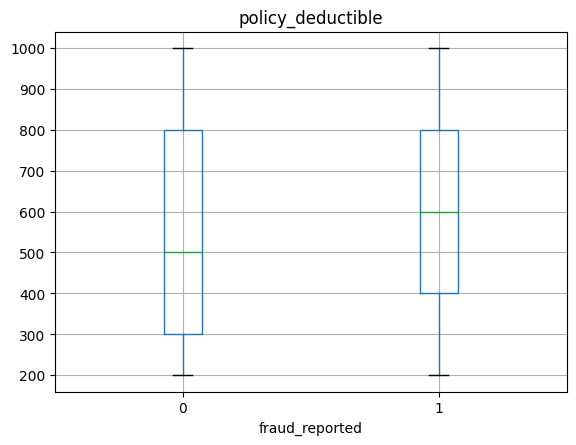

<Figure size 600x300 with 0 Axes>

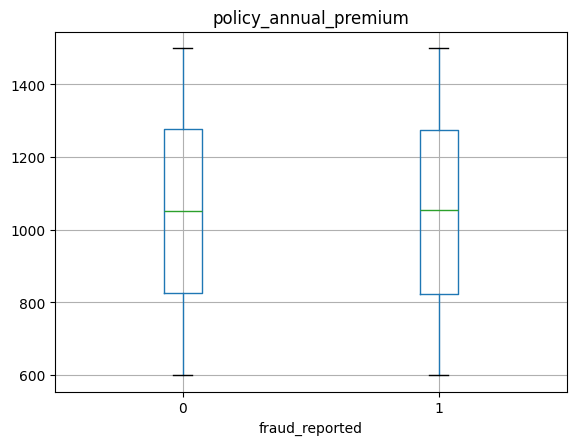

<Figure size 600x300 with 0 Axes>

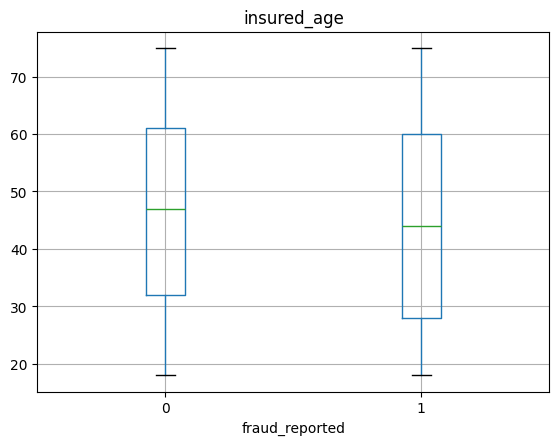

<Figure size 600x300 with 0 Axes>

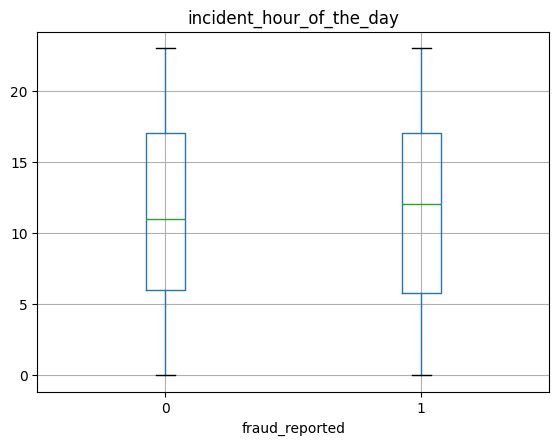

<Figure size 600x300 with 0 Axes>

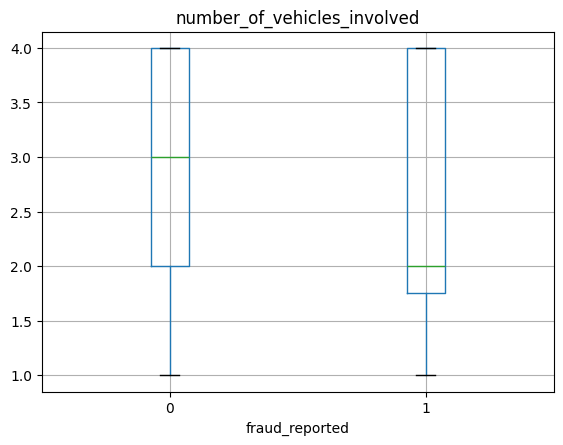

<Figure size 600x300 with 0 Axes>

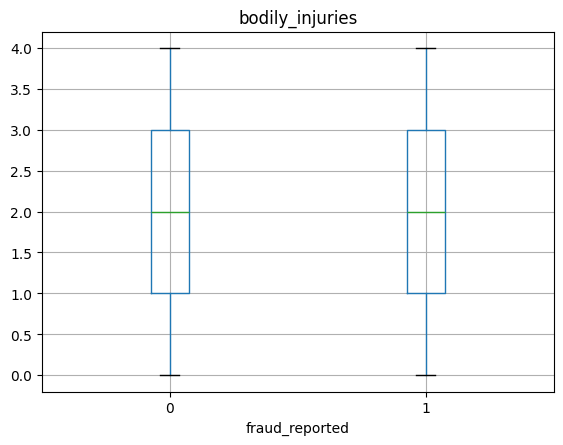

<Figure size 600x300 with 0 Axes>

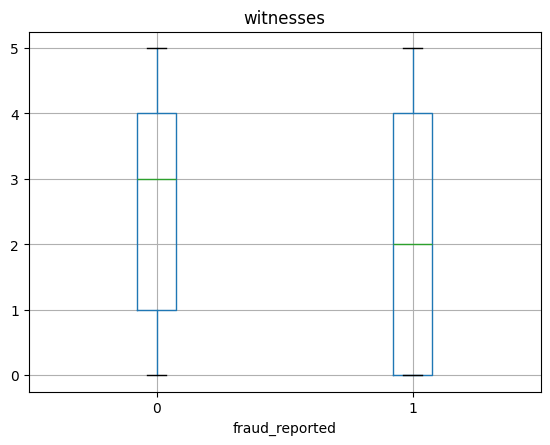

<Figure size 600x300 with 0 Axes>

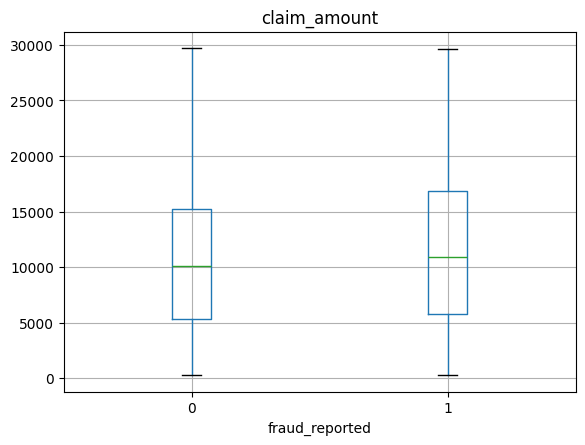

<Figure size 600x300 with 0 Axes>

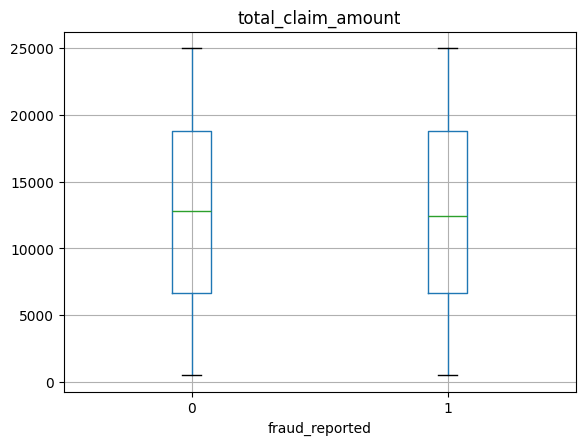

In [ ]:
numeric_cols = ['policy_deductible', 'policy_annual_premium', 'insured_age',
                 'incident_hour_of_the_day', 'number_of_vehicles_involved',
                 'bodily_injuries', 'witnesses', 'claim_amount', 'total_claim_amount']

# Quick numeric summary split by fraud label
print(df.groupby('fraud_reported')[numeric_cols].mean())

# Visual check for each column
for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    df.boxplot(column=col, by='fraud_reported')
    plt.title(col)
    plt.suptitle('')
    plt.show()

In [ ]:
categorical_cols = ['policy_state', 'insured_sex', 'insured_education_level',
                     'insured_occupation', 'insured_hobbies', 'incident_type',
                     'collision_type', 'incident_severity', 'incident_state',
                     'police_report_available']

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df.groupby(col)['fraud_reported'].value_counts(normalize=True).unstack())


--- policy_state ---
fraud_reported         0         1
policy_state                      
CA              0.882413  0.117587
FL              0.886951  0.113049
GA              0.882541  0.117459
IL              0.885974  0.114026
MI              0.885486  0.114514
NC              0.883612  0.116388
NY              0.895847  0.104153
OH              0.889954  0.110046
PA              0.882216  0.117784
TX              0.878049  0.121951

--- insured_sex ---
fraud_reported         0         1
insured_sex                       
FEMALE          0.886785  0.113215
MALE            0.882036  0.117964
OTHER           0.887193  0.112807

--- insured_education_level ---
fraud_reported                  0         1
insured_education_level                    
College                  0.888263  0.111737
High School              0.884564  0.115436
Masters                  0.886987  0.113013
PhD                      0.881554  0.118446

--- insured_occupation ---
fraud_reported             0         

In [ ]:
for col in categorical_cols:
    summary = (
        df.groupby(col)['fraud_reported']
          .agg(fraud_rate="mean", claims="size")
          .sort_values("fraud_rate", ascending=False)
    )
    print(f"\n--- {col} | unique={df[col].nunique()} ---")
    print(summary.head(15))


--- policy_state | unique=10 ---
              fraud_rate  claims
policy_state                    
TX              0.121951    2911
PA              0.117784    2997
CA              0.117587    2951
GA              0.117459    3133
NC              0.116388    2990
MI              0.114514    3004
IL              0.114026    2973
FL              0.113049    2981
OH              0.110046    3026
NY              0.104153    3034

--- insured_sex | unique=3 ---
             fraud_rate  claims
insured_sex                    
MALE           0.117964   10037
FEMALE         0.113215    9875
OTHER          0.112807   10088

--- insured_education_level | unique=4 ---
                         fraud_rate  claims
insured_education_level                    
PhD                        0.118446    7514
High School                0.115436    7554
Masters                    0.113013    7477
College                    0.111737    7455

--- insured_occupation | unique=8 ---
                    fraud_rate 

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != "fraud_flag"]

# Numeric summary with outlier thresholds
numeric_summary = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

    numeric_summary.append({
        "column": col,
        "min": df[col].min(),
        "median": df[col].median(),
        "max": df[col].max(),
        "outlier_count": outlier_count,
        "outlier_percent": round(outlier_count / len(df) * 100, 2)
    })

numeric_outliers = (
    pd.DataFrame(numeric_summary)
      .sort_values("outlier_percent", ascending=False)
)

print(numeric_outliers.to_string(index=False))

                     column    min    median      max  outlier_count  outlier_percent
             fraud_reported   0.00     0.000     1.00           3440            11.47
          policy_deductible 200.00   600.000  1000.00              0             0.00
      policy_annual_premium 600.02  1051.155  1499.98              0             0.00
                insured_age  18.00    46.000    75.00              0             0.00
number_of_vehicles_involved   1.00     3.000     4.00              0             0.00
   incident_hour_of_the_day   0.00    12.000    23.00              0             0.00
            bodily_injuries   0.00     2.000     4.00              0             0.00
                  witnesses   0.00     2.000     5.00              0             0.00
               claim_amount 266.74 10204.170 29719.87              0             0.00
         total_claim_amount 502.18 12740.430 24999.72              0             0.00


In [ ]:
# Temporary derived fields for EDA
df["claim_to_total_ratio"] = (
    df["claim_amount"] / df["total_claim_amount"]
).replace([np.inf, -np.inf], np.nan)

df["claim_total_gap"] = (
    df["total_claim_amount"] - df["claim_amount"]
)

# Overall distribution
print("--- Claim relationship summary ---")
print(
    df[[
        "claim_amount",
        "total_claim_amount",
        "claim_to_total_ratio",
        "claim_total_gap"
    ]].describe().T
)

# Compare these values between legitimate and fraud claims
print("\n--- By fraud label ---")
print(
    df.groupby("fraud_reported")[[
        "claim_amount",
        "total_claim_amount",
        "claim_to_total_ratio",
        "claim_total_gap"
    ]].agg(["mean", "median", "std"])
)

# Check whether the two original amounts move together
print("\n--- Correlation ---")
print(
    df[["claim_amount", "total_claim_amount"]]
      .corr()
)


--- Claim relationship summary ---
                        count          mean          std          min  \
claim_amount          30000.0  10823.078981  6629.690781   266.740000   
total_claim_amount    30000.0  12757.736600  7028.920069   502.180000   
claim_to_total_ratio  30000.0      0.848913     0.201535     0.500094   
claim_total_gap       30000.0   1934.657619  3125.533239 -4914.590000   

                              25%           50%           75%           max  
claim_amount          5350.947500  10204.170000  15381.867500  29719.870000  
total_claim_amount    6685.507500  12740.430000  18809.910000  24999.720000  
claim_to_total_ratio     0.675012      0.848051      1.022217      1.199997  
claim_total_gap       -143.777500   1205.530000   3693.755000  12467.420000  

--- By fraud label ---
               claim_amount                         total_claim_amount  \
                       mean     median          std               mean   
fraud_reported                       

In [ ]:
# Parse dates without overwriting the original columns
df["policy_bind_date_parsed"] = pd.to_datetime(
    df["policy_bind_date"],
    errors="coerce"
)

df["incident_date_parsed"] = pd.to_datetime(
    df["incident_date"],
    errors="coerce"
)

# Basic date-quality check
print("--- Date quality ---")
for col in ["policy_bind_date_parsed", "incident_date_parsed"]:
    print(
        f"{col}:",
        "min =", df[col].min(),
        "| max =", df[col].max(),
        "| missing =", df[col].isna().sum()
    )

# Time elapsed from policy start to incident
df["policy_tenure_days"] = (
    df["incident_date_parsed"] - df["policy_bind_date_parsed"]
).dt.days

print("\n--- Policy tenure summary ---")
print(df["policy_tenure_days"].describe())

print("\nNegative-tenure records:")
print((df["policy_tenure_days"] < 0).sum())

# Check fraud rate by incident month
df["incident_month"] = df["incident_date_parsed"].dt.month

print("\n--- Fraud rate by incident month ---")
print(
    df.groupby("incident_month")["fraud_reported"]
      .agg(fraud_rate="mean", claim_count="size")
      .sort_index()
)

KeyError: 'policy_bind_date'

In [ ]:
print(df.columns.tolist())

print("\nColumns that may contain dates:")
date_candidates = [
    col for col in df.columns
    if any(word in col.lower() for word in ["date", "time", "year", "month", "day"])
]

print(date_candidates)

['policy_state', 'policy_deductible', 'policy_annual_premium', 'insured_age', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'incident_date', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'police_report_available', 'claim_amount', 'total_claim_amount', 'fraud_reported', 'claim_to_total_ratio', 'claim_total_gap']

Columns that may contain dates:
['incident_date', 'incident_hour_of_the_day']


In [ ]:
# Parse incident date
df["incident_date_parsed"] = pd.to_datetime(
    df["incident_date"],
    errors="coerce"
)

print("--- Incident-date quality ---")
print("Earliest date:", df["incident_date_parsed"].min())
print("Latest date:", df["incident_date_parsed"].max())
print("Missing/invalid dates:", df["incident_date_parsed"].isna().sum())

# Temporary EDA fields
df["incident_month"] = df["incident_date_parsed"].dt.month
df["incident_day_of_week"] = df["incident_date_parsed"].dt.day_name()

print("\n--- Fraud rate by incident month ---")
print(
    df.groupby("incident_month")["fraud_reported"]
      .agg(fraud_rate="mean", claim_count="size")
      .sort_index()
)

print("\n--- Fraud rate by day of week ---")
print(
    df.groupby("incident_day_of_week")["fraud_reported"]
      .agg(fraud_rate="mean", claim_count="size")
      .sort_values("fraud_rate", ascending=False)
)

--- Incident-date quality ---
Earliest date: 2023-11-09 00:00:00
Latest date: 2025-11-08 00:00:00
Missing/invalid dates: 0

--- Fraud rate by incident month ---
                fraud_rate  claim_count
incident_month                         
1                 0.112468         2703
2                 0.112431         2357
3                 0.113672         2560
4                 0.109917         2420
5                 0.125493         2534
6                 0.104845         2394
7                 0.117462         2537
8                 0.110940         2596
9                 0.111801         2415
10                0.109466         2567
11                0.132121         2475
12                0.115070         2442

--- Fraud rate by day of week ---
                      fraud_rate  claim_count
incident_day_of_week                         
Monday                  0.118865         4299
Wednesday               0.118749         4379
Thursday                0.118704         4229
Friday        

In [ ]:
# Numeric feature candidates only; remove the target
numeric_features = df.select_dtypes(include=np.number).columns.tolist()

exclude = ["fraud_reported", "fraud_flag"]
numeric_features = [col for col in numeric_features if col not in exclude]

# Correlation matrix
corr_matrix = df[numeric_features].corr()

# Show only strong correlations
strong_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        col_1 = corr_matrix.columns[i]
        col_2 = corr_matrix.columns[j]
        correlation = corr_matrix.iloc[i, j]

        if abs(correlation) >= 0.70:
            strong_pairs.append({
                "feature_1": col_1,
                "feature_2": col_2,
                "correlation": round(correlation, 3)
            })

strong_pairs_df = pd.DataFrame(strong_pairs)

if strong_pairs_df.empty:
    print("No feature pairs have an absolute correlation of 0.70 or above.")
else:
    print(
        strong_pairs_df
        .sort_values("correlation", key=lambda x: x.abs(), ascending=False)
        .to_string(index=False)
    )

           feature_1          feature_2  correlation
        claim_amount total_claim_amount        0.897
claim_to_total_ratio    claim_total_gap       -0.822


In [ ]:
derived_features = ["claim_to_total_ratio", "claim_total_gap"]

for col in derived_features:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    flag_col = f"{col}_outlier"
    df[flag_col] = (
        (df[col] < lower_bound) | (df[col] > upper_bound)
    ).astype(int)

    print(f"\n--- {col} ---")
    print(f"Lower bound: {lower_bound:.3f}")
    print(f"Upper bound: {upper_bound:.3f}")
    print(f"Flagged records: {df[flag_col].sum()}")

    print(
        df.groupby(flag_col)["fraud_reported"]
          .agg(fraud_rate="mean", claim_count="size")
    )


--- claim_to_total_ratio ---
Lower bound: 0.154
Upper bound: 1.543
Flagged records: 0
                              fraud_rate  claim_count
claim_to_total_ratio_outlier                         
0                               0.114667        30000

--- claim_total_gap ---
Lower bound: -5900.076
Upper bound: 9450.054
Flagged records: 728
                         fraud_rate  claim_count
claim_total_gap_outlier                         
0                          0.115742        29272
1                          0.071429          728


In [ ]:
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

placeholder_values = {
    "", " ", "none", "nan", "null", "unknown",
    "n/a", "na", "?"
}

placeholder_summary = []

for col in categorical_cols:
    normalized = df[col].astype(str).str.strip().str.lower()

    placeholder_count = normalized.isin(placeholder_values).sum()

    if placeholder_count > 0:
        placeholder_summary.append({
            "column": col,
            "placeholder_count": placeholder_count,
            "placeholder_percent": round(placeholder_count / len(df) * 100, 2),
            "values_found": sorted(
                df.loc[normalized.isin(placeholder_values), col]
                  .astype(str)
                  .unique()
                  .tolist()
            )
        })

placeholder_df = pd.DataFrame(placeholder_summary)

if placeholder_df.empty:
    print("No text-based missing-value placeholders found.")
else:
    print(placeholder_df.to_string(index=False))

               column  placeholder_count  placeholder_percent values_found
       collision_type               7433                24.78    [Unknown]
authorities_contacted               7564                25.21       [None]


In [ ]:
for col in ["collision_type", "authorities_contacted"]:
    print(f"\n--- {col} ---")

    print(
        df.groupby(col, dropna=False)["fraud_reported"]
          .agg(
              fraud_rate="mean",
              claim_count="size"
          )
          .sort_values("fraud_rate", ascending=False)
    )


--- collision_type ---
                fraud_rate  claim_count
collision_type                         
Rear              0.114988         7566
Side              0.114864         7461
Unknown           0.114489         7433
Front             0.114324         7540

--- authorities_contacted ---
                       fraud_rate  claim_count
authorities_contacted                         
None                     0.211264         7564
Ambulance                0.084815         7369
Fire                     0.083763         7569
Police                   0.077754         7498


In [ ]:
# Keep the original df unchanged
model_df = df.copy()

# Target: retain separately for later evaluation only
y = model_df["fraud_reported"].copy()

# Date-derived features
model_df["incident_year"] = model_df["incident_date_parsed"].dt.year
model_df["incident_month"] = model_df["incident_date_parsed"].dt.month
model_df["incident_day_of_week_num"] = (
    model_df["incident_date_parsed"].dt.dayofweek
)

# Remove raw date and temporary/helper columns
columns_to_drop = [
    "fraud_reported",             # evaluation label, never a model feature
    "incident_date",              # replaced by derived calendar features
    "incident_date_parsed",       # helper date column
    "incident_day_of_week",       # replaced by numeric version
    "claim_amount",               # redundant with total + ratio
    "claim_total_gap",            # mathematically derived from total + ratio
    "claim_to_total_ratio_outlier",
    "claim_total_gap_outlier"
]

columns_to_drop = [
    col for col in columns_to_drop
    if col in model_df.columns
]

X_raw = model_df.drop(columns=columns_to_drop)

print("Feature-table shape:", X_raw.shape)
print("\nFeature columns:")
print(X_raw.columns.tolist())

print("\nMissing values:")
print(X_raw.isna().sum()[X_raw.isna().sum() > 0])

Feature-table shape: (30000, 23)

Feature columns:
['policy_state', 'policy_deductible', 'policy_annual_premium', 'insured_age', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'police_report_available', 'total_claim_amount', 'claim_to_total_ratio', 'incident_month', 'incident_year', 'incident_day_of_week_num']

Missing values:
Series([], dtype: int64)


In [ ]:

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training features:", X_train_raw.shape)
print("Test features:", X_test_raw.shape)

print("\n--- Training fraud distribution ---")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True).round(4))

print("\n--- Test fraud distribution ---")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True).round(4))

Training features: (24000, 23)
Test features: (6000, 23)

--- Training fraud distribution ---
fraud_reported
0    21248
1     2752
Name: count, dtype: int64
fraud_reported
0    0.8853
1    0.1147
Name: proportion, dtype: float64

--- Test fraud distribution ---
fraud_reported
0    5312
1     688
Name: count, dtype: int64
fraud_reported
0    0.8853
1    0.1147
Name: proportion, dtype: float64


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import IsolationForest

In [ ]:
# Treat calendar fields as categories, not as ordered numbers
calendar_categorical = [
    "incident_month",
    "incident_year",
    "incident_day_of_week_num"
]

categorical_features = (
    X_train_raw.select_dtypes(include=["object", "category"])
    .columns
    .tolist()
)

categorical_features += [
    col for col in calendar_categorical
    if col not in categorical_features
]

numeric_features = [
    col for col in X_train_raw.columns
    if col not in categorical_features
]

print("Categorical features:", categorical_features)
print("\nNumeric features:", numeric_features)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features
        ),
        ("numeric", "passthrough", numeric_features)
    ],
    remainder="drop"
)

# Learn categories from training data only
X_train_encoded = preprocessor.fit_transform(X_train_raw)
X_test_encoded = preprocessor.transform(X_test_raw)

feature_names = preprocessor.get_feature_names_out()

print("\nEncoded training shape:", X_train_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)
print("Number of final model features:", len(feature_names))

Categorical features: ['policy_state', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'police_report_available', 'incident_month', 'incident_year', 'incident_day_of_week_num']

Numeric features: ['policy_deductible', 'policy_annual_premium', 'insured_age', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'total_claim_amount', 'claim_to_total_ratio']

Encoded training shape: (24000, 90)
Encoded test shape: (6000, 90)
Number of final model features: 90


In [ ]:
# Train only on known legitimate claims
X_train_normal = X_train_encoded[y_train.to_numpy() == 0]

print("Legitimate claims used for training:", X_train_normal.shape)

# 11.47% is the observed fraud rate.
# This sets the approximate share of claims the model will flag for review.
iso_forest = IsolationForest(
    n_estimators=300,
    contamination=0.1147,
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_train_normal)

print("Isolation Forest training complete.")

Legitimate claims used for training: (21248, 90)
Isolation Forest training complete.


In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
# Higher score = more anomalous / more suspicious
test_anomaly_score = -iso_forest.decision_function(X_test_encoded)

# Isolation Forest returns -1 for anomaly and +1 for normal
test_anomaly_flag = (
    iso_forest.predict(X_test_encoded) == -1
).astype(int)

print("Flagged as anomalous:", test_anomaly_flag.sum())
print("Flagged percentage:", round(test_anomaly_flag.mean() * 100, 2), "%")

print("\n--- Metrics ---")
print("ROC-AUC:   ", round(roc_auc_score(y_test, test_anomaly_score), 4))
print("Precision: ", round(precision_score(y_test, test_anomaly_flag), 4))
print("Recall:    ", round(recall_score(y_test, test_anomaly_flag), 4))
print("F1 score:  ", round(f1_score(y_test, test_anomaly_flag), 4))

print("\n--- Confusion matrix ---")
print(confusion_matrix(y_test, test_anomaly_flag))

print("\n--- Classification report ---")
print(classification_report(y_test, test_anomaly_flag))

Flagged as anomalous: 719
Flagged percentage: 11.98 %

--- Metrics ---
ROC-AUC:    0.5065
Precision:  0.1168
Recall:     0.1221
F1 score:   0.1194

--- Confusion matrix ---
[[4677  635]
 [ 604   84]]

--- Classification report ---
              precision    recall  f1-score   support

           0       0.89      0.88      0.88      5312
           1       0.12      0.12      0.12       688

    accuracy                           0.79      6000
   macro avg       0.50      0.50      0.50      6000
weighted avg       0.80      0.79      0.80      6000



In [ ]:
# Keep test-row identifiers using the original dataframe index
isolation_results = pd.DataFrame({
    "row_index": X_test_raw.index,
    "actual_fraud": y_test.to_numpy(),
    "anomaly_score": test_anomaly_score,
    "anomaly_flag": test_anomaly_flag
})

# Sort so the most suspicious claims are first
isolation_results = isolation_results.sort_values(
    "anomaly_score",
    ascending=False
)

print(isolation_results.head(10))

print("\nSaved-result shape:", isolation_results.shape)

      row_index  actual_fraud  anomaly_score  anomaly_flag
1133      13400             0       0.023415             1
3932      15880             0       0.021621             1
5574      16848             0       0.021147             1
4865      22158             0       0.020375             1
5501      16416             0       0.020212             1
2464        553             0       0.018974             1
492        4913             0       0.018784             1
4126      22106             0       0.018034             1
1530      13951             0       0.017987             1
2898      12442             0       0.017892             1

Saved-result shape: (6000, 4)


In [ ]:
inspection_columns = [
    "fraud_reported",
    "authorities_contacted",
    "incident_severity",
    "collision_type",
    "incident_type",
    "insured_occupation",
    "claim_amount",
    "total_claim_amount",
    "claim_to_total_ratio",
    "claim_total_gap",
    "number_of_vehicles_involved",
    "bodily_injuries",
    "witnesses"
]

top_anomaly_rows = (
    df.loc[isolation_results.head(10)["row_index"], inspection_columns]
      .copy()
)

top_anomaly_rows.insert(
    0,
    "anomaly_score",
    isolation_results.head(10)["anomaly_score"].to_numpy()
)

print(top_anomaly_rows.to_string())

       anomaly_score  fraud_reported authorities_contacted incident_severity collision_type  incident_type insured_occupation  claim_amount  total_claim_amount  claim_to_total_ratio  claim_total_gap  number_of_vehicles_involved  bodily_injuries  witnesses
13400       0.023415               0                Police        Total Loss        Unknown  Vehicle Theft             Lawyer      16254.43            24708.62              0.657845          8454.19                            4                4          3
15880       0.021621               0                  Fire      Minor Damage           Rear  Vehicle Theft            Manager      13610.92            16149.22              0.842822          2538.30                            1                4          1
16848       0.021147               0                  None      Minor Damage           Rear  Vehicle Theft            Teacher       8094.05             6787.67              1.192464         -1306.38                            1     

In [ ]:
from pathlib import Path

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

metrics_df = pd.DataFrame([{
    "model": "Isolation Forest",
    "train_rows": len(X_train_normal),
    "test_rows": len(X_test_raw),
    "contamination": 0.1147,
    "roc_auc": roc_auc_score(y_test, test_anomaly_score),
    "precision": precision_score(y_test, test_anomaly_flag),
    "recall": recall_score(y_test, test_anomaly_flag),
    "f1_score": f1_score(y_test, test_anomaly_flag),
    "flagged_claims": int(test_anomaly_flag.sum())
}])

isolation_results.to_parquet(
    output_dir / "isolation_forest_predictions.parquet",
    index=False
)

metrics_df.to_parquet(
    output_dir / "isolation_forest_metrics.parquet",
    index=False
)

print(metrics_df.to_string(index=False))
print("\nSaved files:")
print(output_dir / "isolation_forest_predictions.parquet")
print(output_dir / "isolation_forest_metrics.parquet")

           model  train_rows  test_rows  contamination  roc_auc  precision   recall  f1_score  flagged_claims
Isolation Forest       21248       6000         0.1147  0.50645   0.116829 0.122093  0.119403             719

Saved files:
outputs/isolation_forest_predictions.parquet
outputs/isolation_forest_metrics.parquet


In [ ]:
import joblib
import json

# Save trained model
joblib.dump(
    iso_forest,
    output_dir / "isolation_forest_model.joblib"
)

# Save the fitted one-hot encoder/preprocessing pipeline
joblib.dump(
    preprocessor,
    output_dir / "isolation_forest_preprocessor.joblib"
)

# Save the exact raw input-column order expected by the preprocessor
with open(output_dir / "isolation_forest_input_columns.json", "w") as file:
    json.dump(X_raw.columns.tolist(), file, indent=2)

print("Saved files:")
print(output_dir / "isolation_forest_model.joblib")
print(output_dir / "isolation_forest_preprocessor.joblib")
print(output_dir / "isolation_forest_input_columns.json")


Saved files:
outputs/isolation_forest_model.joblib
outputs/isolation_forest_preprocessor.joblib
outputs/isolation_forest_input_columns.json


In [ ]:
# Feature-engineered tabular dataset, including ID and label for downstream work
silver_tabular_df = X_raw.copy()

silver_tabular_df.insert(0, "row_index", X_raw.index)
silver_tabular_df["fraud_reported"] = y

silver_tabular_df.to_parquet(
    output_dir / "claims_tabular_features.parquet",
    index=False
)

print("Saved:", output_dir / "claims_tabular_features.parquet")
print("Shape:", silver_tabular_df.shape)

print("\nColumns:")
print(silver_tabular_df.columns.tolist())

Saved: outputs/claims_tabular_features.parquet
Shape: (30000, 25)

Columns:
['row_index', 'policy_state', 'policy_deductible', 'policy_annual_premium', 'insured_age', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'police_report_available', 'total_claim_amount', 'claim_to_total_ratio', 'incident_month', 'incident_year', 'incident_day_of_week_num', 'fraud_reported']


In [ ]:
summary_text = f"""# Isolation Forest - Tabular Anomaly Detection

## Purpose
Detect unusual insurance claims from structured/tabular data and produce an anomaly score for investigator triage.

## Dataset
- Records: 30,000
- Fraud rate: 11.47%
- Training records: 24,000
- Test records: 6,000
- Isolation Forest trained on legitimate training claims only: 21,248

## Key EDA findings
- `authorities_contacted = None` had the highest fraud rate: 21.13%.
- `incident_severity = Total Loss` had a higher fraud rate: 14.81%.
- `claim_to_total_ratio` was higher for fraud claims.
- No major univariate numeric outliers were present.
- Claim amount and total claim amount were strongly correlated (0.897).

## Model configuration
- Isolation Forest
- n_estimators: 300
- contamination: 0.1147
- Random state: 42
- Final encoded features: 90

## Evaluation
- ROC-AUC: 0.5065
- Precision: 0.1168
- Recall: 0.1221
- F1-score: 0.1194
- Claims flagged for review: 719

## Interpretation
Isolation Forest identified unusual tabular patterns but did not effectively separate known fraud claims from legitimate claims. Its anomaly score should be used as a supplementary risk signal alongside the later supervised XGBoost/LightGBM fusion model.

## Deliverables
- `claims_tabular_features.parquet`
- `isolation_forest_predictions.parquet`
- `isolation_forest_metrics.parquet`
- `isolation_forest_model.joblib`
- `isolation_forest_preprocessor.joblib`
- `isolation_forest_input_columns.json`
"""

with open(output_dir / "README_isolation_forest.md", "w") as file:
    file.write(summary_text)

print("Saved:", output_dir / "README_isolation_forest.md")

Saved: outputs/README_isolation_forest.md


In [ ]:
import xgboost as xgb
from xgboost import XGBClassifier

In [ ]:
# Fraud is the positive/minority class
negative_claims = (y_train == 0).sum()
positive_claims = (y_train == 1).sum()

scale_pos_weight = negative_claims / positive_claims

print("XGBoost version:", xgb.__version__)
print("Legitimate training claims:", negative_claims)
print("Fraud training claims:", positive_claims)
print("scale_pos_weight:", round(scale_pos_weight, 4))

print("\nTraining matrix:", X_train_encoded.shape)
print("Test matrix:", X_test_encoded.shape)

XGBoost version: 3.4.1
Legitimate training claims: 21248
Fraud training claims: 2752
scale_pos_weight: 7.7209

Training matrix: (24000, 90)
Test matrix: (6000, 90)


In [ ]:
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=3,
    subsample=0.80,
    colsample_bytree=0.80,
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

xgb_model.fit(X_train_encoded, y_train)

print("XGBoost training complete.")
print("Number of trees:", xgb_model.n_estimators)

XGBoost training complete.
Number of trees: 500


In [ ]:
# Probability that each test claim is fraudulent
xgb_test_probability = xgb_model.predict_proba(X_test_encoded)[:, 1]

# Default classification threshold
xgb_test_prediction = (xgb_test_probability >= 0.50).astype(int)

print("Claims predicted as fraud:", xgb_test_prediction.sum())
print("Predicted-fraud percentage:", round(xgb_test_prediction.mean() * 100, 2), "%")

print("\n--- Metrics at threshold = 0.50 ---")
print("ROC-AUC:   ", round(roc_auc_score(y_test, xgb_test_probability), 4))
print("Precision: ", round(precision_score(y_test, xgb_test_prediction), 4))
print("Recall:    ", round(recall_score(y_test, xgb_test_prediction), 4))
print("F1 score:  ", round(f1_score(y_test, xgb_test_prediction), 4))

print("\n--- Confusion matrix ---")
print(confusion_matrix(y_test, xgb_test_prediction))

print("\n--- Classification report ---")
print(classification_report(y_test, xgb_test_prediction))

Claims predicted as fraud: 1030
Predicted-fraud percentage: 17.17 %

--- Metrics at threshold = 0.50 ---
ROC-AUC:    0.749
Precision:  0.3864
Recall:     0.5785
F1 score:   0.4633

--- Confusion matrix ---
[[4680  632]
 [ 290  398]]

--- Classification report ---
              precision    recall  f1-score   support

           0       0.94      0.88      0.91      5312
           1       0.39      0.58      0.46       688

    accuracy                           0.85      6000
   macro avg       0.66      0.73      0.69      6000
weighted avg       0.88      0.85      0.86      6000



In [ ]:
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print(feature_importance_df.head(20).to_string(index=False))

                                     feature  importance
     categorical__authorities_contacted_None    0.058811
   categorical__incident_severity_Total Loss    0.041754
                          numeric__witnesses    0.028249
 categorical__incident_severity_Major Damage    0.027776
   categorical__authorities_contacted_Police    0.027367
     categorical__authorities_contacted_Fire    0.026162
       categorical__insured_occupation_Sales    0.024178
       categorical__insured_occupation_Clerk    0.022277
 categorical__incident_severity_Minor Damage    0.019901
categorical__authorities_contacted_Ambulance    0.017565
               numeric__claim_to_total_ratio    0.016761
                        numeric__insured_age    0.013368
               categorical__incident_month_1    0.010285
      categorical__insured_occupation_Lawyer    0.009922
               categorical__incident_month_5    0.009826
    categorical__insured_occupation_Engineer    0.009775
     categorical__incident_day_

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve

In [ ]:
# Split existing training data into model-training and validation portions
train_idx, val_idx = train_test_split(
    range(len(y_train)),
    test_size=0.20,
    stratify=y_train,
    random_state=42
)

X_model_train = X_train_encoded[train_idx]
X_validation = X_train_encoded[val_idx]

y_model_train = y_train.iloc[train_idx]
y_validation = y_train.iloc[val_idx]

# Train a separate model solely for threshold selection
xgb_threshold_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=3,
    subsample=0.80,
    colsample_bytree=0.80,
    scale_pos_weight=(y_model_train == 0).sum() / (y_model_train == 1).sum(),
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

xgb_threshold_model.fit(X_model_train, y_model_train)

validation_probability = xgb_threshold_model.predict_proba(X_validation)[:, 1]

precision, recall, thresholds = precision_recall_curve(
    y_validation,
    validation_probability
)

f1_scores = (
    2 * precision[:-1] * recall[:-1] /
    (precision[:-1] + recall[:-1] + 1e-10)
)

best_index = f1_scores.argmax()
best_threshold = thresholds[best_index]

print("Best validation threshold:", round(best_threshold, 4))
print("Best validation F1:", round(f1_scores[best_index], 4))
print("Validation precision:", round(precision[best_index], 4))
print("Validation recall:", round(recall[best_index], 4))


Best validation threshold: 0.4756
Best validation F1: 0.4698
Validation precision: 0.3853
Validation recall: 0.6018


In [ ]:
xgb_final_threshold = best_threshold

xgb_final_prediction = (
    xgb_test_probability >= xgb_final_threshold
).astype(int)

print("Final threshold:", round(xgb_final_threshold, 4))
print("Claims predicted as fraud:", xgb_final_prediction.sum())
print("Predicted-fraud percentage:", round(xgb_final_prediction.mean() * 100, 2), "%")

print("\n--- Final test metrics ---")
print("ROC-AUC:   ", round(roc_auc_score(y_test, xgb_test_probability), 4))
print("Precision: ", round(precision_score(y_test, xgb_final_prediction), 4))
print("Recall:    ", round(recall_score(y_test, xgb_final_prediction), 4))
print("F1 score:  ", round(f1_score(y_test, xgb_final_prediction), 4))

print("\n--- Confusion matrix ---")
print(confusion_matrix(y_test, xgb_final_prediction))

Final threshold: 0.4756
Claims predicted as fraud: 1060
Predicted-fraud percentage: 17.67 %

--- Final test metrics ---
ROC-AUC:    0.749
Precision:  0.3821
Recall:     0.5887
F1 score:   0.4634

--- Confusion matrix ---
[[4657  655]
 [ 283  405]]


In [ ]:
xgb_results = pd.DataFrame({
    "row_index": X_test_raw.index,
    "actual_fraud": y_test.to_numpy(),
    "fraud_probability": xgb_test_probability,
    "fraud_prediction": xgb_final_prediction
}).sort_values("fraud_probability", ascending=False)

xgb_metrics_df = pd.DataFrame([{
    "model": "XGBoost - tabular only",
    "train_rows": len(X_train_raw),
    "test_rows": len(X_test_raw),
    "feature_count": X_train_encoded.shape[1],
    "threshold": float(xgb_final_threshold),
    "roc_auc": roc_auc_score(y_test, xgb_test_probability),
    "precision": precision_score(y_test, xgb_final_prediction),
    "recall": recall_score(y_test, xgb_final_prediction),
    "f1_score": f1_score(y_test, xgb_final_prediction),
    "predicted_fraud_claims": int(xgb_final_prediction.sum())
}])

xgb_results.to_parquet(
    output_dir / "xgboost_tabular_predictions.parquet",
    index=False
)

xgb_metrics_df.to_parquet(
    output_dir / "xgboost_tabular_metrics.parquet",
    index=False
)

joblib.dump(
    xgb_model,
    output_dir / "xgboost_tabular_model.joblib"
)

print(xgb_metrics_df.to_string(index=False))
print("\nSaved:")
print(output_dir / "xgboost_tabular_predictions.parquet")
print(output_dir / "xgboost_tabular_metrics.parquet")
print(output_dir / "xgboost_tabular_model.joblib")

                 model  train_rows  test_rows  feature_count  threshold  roc_auc  precision   recall  f1_score  predicted_fraud_claims
XGBoost - tabular only       24000       6000             90   0.475642 0.749035   0.382075 0.588663  0.463387                    1060

Saved:
outputs/xgboost_tabular_predictions.parquet
outputs/xgboost_tabular_metrics.parquet
outputs/xgboost_tabular_model.joblib


In [ ]:
comparison_df = pd.DataFrame([
    {
        "model": "Isolation Forest",
        "roc_auc": roc_auc_score(y_test, test_anomaly_score),
        "precision": precision_score(y_test, test_anomaly_flag),
        "recall": recall_score(y_test, test_anomaly_flag),
        "f1_score": f1_score(y_test, test_anomaly_flag),
        "flagged_or_predicted_fraud": int(test_anomaly_flag.sum())
    },
    {
        "model": "XGBoost - tabular only",
        "roc_auc": roc_auc_score(y_test, xgb_test_probability),
        "precision": precision_score(y_test, xgb_final_prediction),
        "recall": recall_score(y_test, xgb_final_prediction),
        "f1_score": f1_score(y_test, xgb_final_prediction),
        "flagged_or_predicted_fraud": int(xgb_final_prediction.sum())
    }
])

comparison_df.to_parquet(
    output_dir / "tabular_model_comparison.parquet",
    index=False
)

print(comparison_df.to_string(index=False))
print("\nSaved:", output_dir / "tabular_model_comparison.parquet")



                 model  roc_auc  precision   recall  f1_score  flagged_or_predicted_fraud
      Isolation Forest 0.506450   0.116829 0.122093  0.119403                         719
XGBoost - tabular only 0.749035   0.382075 0.588663  0.463387                        1060

Saved: outputs/tabular_model_comparison.parquet


In [ ]:
!pwd
!git status
!git remote -v

/content
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


In [ ]:
!git clone https://github.com/Priyanshu631/npnhackathonpython.git
%cd /content/npnhackathonpython
!git status
!git branch --show-current

Cloning into 'npnhackathonpython'...
remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 10 (delta 1), reused 10 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (10/10), done.
Resolving deltas: 100% (1/1), done.
/content/npnhackathonpython
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
main


In [ ]:
!find /content/outputs -maxdepth 1 -type f -printf "%f\n"
!find /content -maxdepth 1 -type f -printf "%f\n"

isolation_forest_model.joblib
isolation_forest_metrics.parquet
isolation_forest_predictions.parquet
isolation_forest_preprocessor.joblib
isolation_forest_input_columns.json
xgboost_tabular_metrics.parquet
xgboost_tabular_predictions.parquet
tabular_model_comparison.parquet
claims_tabular_features.parquet
xgboost_tabular_model.joblib
README_isolation_forest.md


In [ ]:
!find . -maxdepth 2 -type f -not -path "./.git/*" -printf "%p\n"

./main.py
./readme.md
./Dockerfile
./.dockerignore
./.gitignore
./requirements.txt


In [ ]:
!mkdir -p gold
!cp /content/outputs/* gold/

!find gold -maxdepth 1 -type f -printf "%f\n"

isolation_forest_model.joblib
isolation_forest_metrics.parquet
isolation_forest_predictions.parquet
isolation_forest_preprocessor.joblib
isolation_forest_input_columns.json
xgboost_tabular_metrics.parquet
xgboost_tabular_predictions.parquet
tabular_model_comparison.parquet
claims_tabular_features.parquet
xgboost_tabular_model.joblib
README_isolation_forest.md


In [ ]:
!mkdir -p silver
!mv gold/claims_tabular_features.parquet silver/claims_tabular_features.parquet

!find silver -maxdepth 1 -type f -printf "%f\n"
!find gold -maxdepth 1 -type f -printf "%f\n"

claims_tabular_features.parquet
isolation_forest_model.joblib
isolation_forest_metrics.parquet
isolation_forest_predictions.parquet
isolation_forest_preprocessor.joblib
isolation_forest_input_columns.json
xgboost_tabular_metrics.parquet
xgboost_tabular_predictions.parquet
tabular_model_comparison.parquet
xgboost_tabular_model.joblib
README_isolation_forest.md


In [65]:
!zip -r /content/tabular_model_deliverables.zip \
  /content/npnhackathonpython/silver \
  /content/npnhackathonpython/gold

from google.colab import files
files.download("/content/tabular_model_deliverables.zip")

  adding: content/npnhackathonpython/silver/ (stored 0%)
  adding: content/npnhackathonpython/silver/claims_tabular_features.parquet (deflated 18%)
  adding: content/npnhackathonpython/gold/ (stored 0%)
  adding: content/npnhackathonpython/gold/isolation_forest_model.joblib (deflated 75%)
  adding: content/npnhackathonpython/gold/isolation_forest_metrics.parquet (deflated 69%)
  adding: content/npnhackathonpython/gold/isolation_forest_predictions.parquet (deflated 18%)
  adding: content/npnhackathonpython/gold/isolation_forest_preprocessor.joblib (deflated 71%)
  adding: content/npnhackathonpython/gold/isolation_forest_input_columns.json (deflated 56%)
  adding: content/npnhackathonpython/gold/xgboost_tabular_metrics.parquet (deflated 70%)
  adding: content/npnhackathonpython/gold/xgboost_tabular_predictions.parquet (deflated 14%)
  adding: content/npnhackathonpython/gold/tabular_model_comparison.parquet (deflated 62%)
  adding: content/npnhackathonpython/gold/xgboost_tabular_model.job

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>